In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

In [2]:
from spectral_mixture_analysis.audio import load_mono_audio, match_length, mix_signals
from spectral_mixture_analysis.transforms import (
    compute_stft_complex,
    magnitude_spectrogram,
    amplitude_to_db,
)
from spectral_mixture_analysis.metrics import l2_error, relative_l2_error
from spectral_mixture_analysis.plotting import plot_spectrogram, plot_difference_map

In [4]:
audio_path_1 = PROJECT_ROOT / "data" / "raw" / "audio1_bass.wav"
audio_path_2 = PROJECT_ROOT / "data" / "raw" / "audio2_vocal.wav"

x, sr = load_mono_audio(audio_path_1, sr=22050)
y, _ = load_mono_audio(audio_path_2, sr=22050)

x, y = match_length(x, y, mode="truncate")
mix = mix_signals(x, y, normalize=True)

In [5]:
N_FFT = 2048
HOP = 512

X = compute_stft_complex(x, n_fft=N_FFT, hop_length=HOP)
Y = compute_stft_complex(y, n_fft=N_FFT, hop_length=HOP)
M = compute_stft_complex(mix, n_fft=N_FFT, hop_length=HOP)

mag_x = magnitude_spectrogram(X)
mag_y = magnitude_spectrogram(Y)
mag_mix = magnitude_spectrogram(M)
mag_sum = mag_x + mag_y

mix_db = amplitude_to_db(mag_mix)
sum_db = amplitude_to_db(mag_sum)
diff = mag_mix - mag_sum

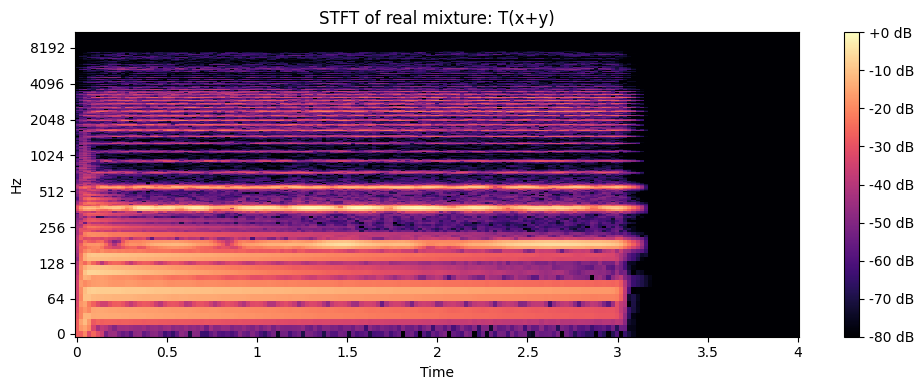

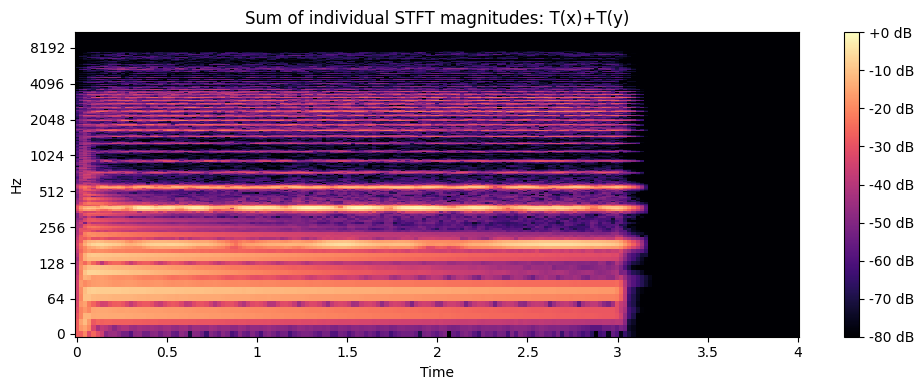

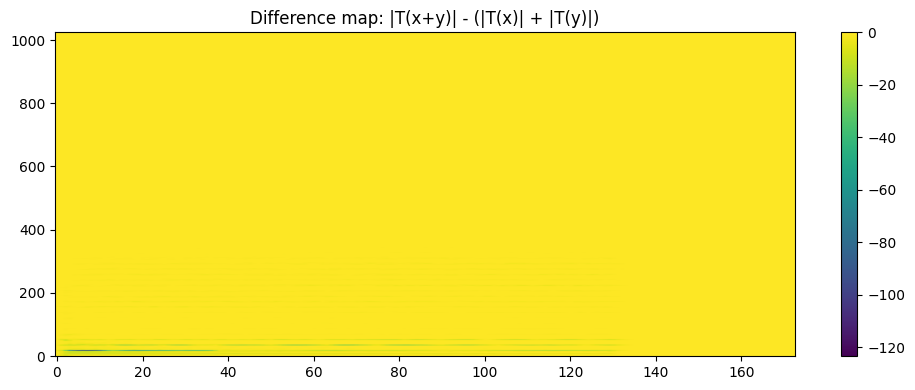

In [6]:
plot_spectrogram(mix_db, sr=sr, hop_length=HOP, title="STFT of real mixture: T(x+y)")
plot_spectrogram(sum_db, sr=sr, hop_length=HOP, title="Sum of individual STFT magnitudes: T(x)+T(y)")
plot_difference_map(diff, title="Difference map: |T(x+y)| - (|T(x)| + |T(y)|)")

In [7]:
print("L2 error:", l2_error(mag_mix, mag_sum))
print("Relative L2 error:", relative_l2_error(mag_mix, mag_sum))

L2 error: 661.686279296875
Relative L2 error: 0.21035607159137726
